In [26]:
%run general_functions.ipynb

In [27]:
import os
folder = '/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/'

# List all NetCDF files (assuming consistent naming)
files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.nc')])

# Extract dates from filenames (customize this depending on your file naming)
dates = [pd.to_datetime(os.path.basename(f).split('_y')[1].split('.')[0], format='%Y') for f in files]

In [28]:
datasets = []
for file, date in zip(files, dates):
    ds = xr.open_dataset(file)
    # Add time dimension to dataset, expanding dims to insert time coordinate
    ds_expanded = ds.expand_dims({'time': [date]})
    datasets.append(ds_expanded)
    ds_expanded.to_netcdf(f'/Users/chiaraciscato/Desktop/alk_mask_try/{date}_alk.nc')

In [20]:
combined = xr.concat(datasets, dim='time')

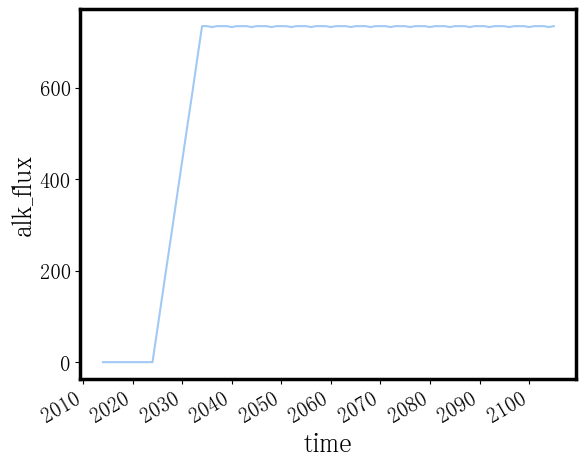

In [22]:
combined['alk_flux'].sum(dim=['x','y']).plot()

In [4]:
co2flux_base = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/co2flux_base70_lastDecade.nc')
co2flux_oae = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/co2flux_oae70_lastDecade.nc')

In [5]:
filepaths = sorted(glob.glob("/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/*.nc"))

datasets = []
start_year = 2014

for i, fp in enumerate(filepaths):
    ds = xr.open_dataset(fp)
    # Add a fake time dimension (as one time step per file)
    year = start_year + i
    ds = ds.expand_dims(time=[pd.Timestamp(f"{year}-01-01")])
    datasets.append(ds)

# # 3. Concatenate along time
ds_merged = xr.concat(datasets, dim="time")

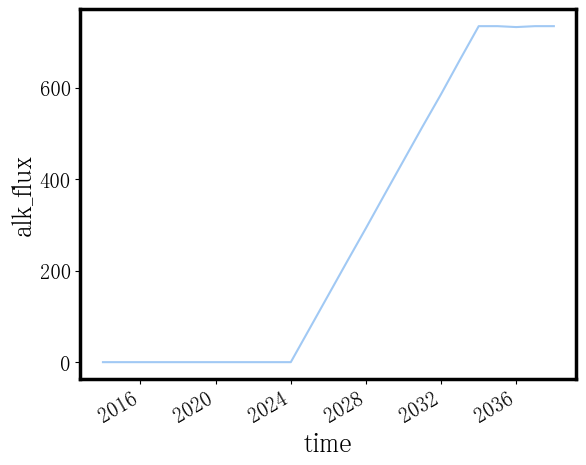

In [7]:
ds_merged['alk_flux'].isel(time=slice(0,25)).sum(dim=['x','y']).plot()

In [43]:
ds_merged['alk_flux'].max()

<xarray.DataArray 'alk_flux' ()>
array(1.41619315)

In [44]:
# ocean mask

mesk_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')
dx, dy = mesk_mask.e1t, mesk_mask.e2t
grid_cell_area = (dx * dy).isel(t=0)

mesk_mask['tmask'] = mesk_mask['tmask'].where(mesk_mask['tmask']!=0)
grid_cell_ocean = (mesk_mask['tmask'].isel(t=0,z=0)*grid_cell_area)
grid_cell_ocean = grid_cell_ocean.where(grid_cell_ocean)

ocean_slice = grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435)) # m-2

In [45]:
# alkalkinity mask

alk_mask = ds_merged.where(ds_merged)
alk_mask=alk_mask.sel(x=slice(520, 595), y=slice(330, 435), time=slice('2090','2099'))
# alk_mask = alk_mask.where(alk_mask)


alk_mask_nans = xr.where(alk_mask.notnull(), 1, np.nan)
alk_mask_nans = alk_mask_nans.where(alk_mask_nans)
coastline_ocean = (ocean_slice * alk_mask_nans).isel(time=0)

In [19]:
                                        # umol to mol  m-2 to -     s-1 to y-1

alk_mask['alk_flux'] = (alk_mask['alk_flux'] / 1e6  * 31536000 * coastline_ocean['alk_flux']).sum(dim=['x','y']) # mol y-1 

In [46]:
co2flux_change = co2flux_oae - co2flux_base
co2flux_change['co2flux'] = (co2flux_change['co2flux'] * 1000 / 44.009 * 31536000 * ocean_slice).sum(dim=['x','y']) # mol yr-1
co2flux_change = co2flux_change.groupby("time_counter.year").mean("time_counter")

(array([ 4740.,  4740.,     0.,   948.,  8532.,  4740.,   948.,  3792.,
        14220.,  4740.]),
 array([-1.56686985e+13, -1.54019526e+13, -1.51352066e+13, -1.48684607e+13,
        -1.46017147e+13, -1.43349688e+13, -1.40682229e+13, -1.38014769e+13,
        -1.35347310e+13, -1.32679850e+13, -1.30012391e+13]),
 <BarContainer object of 10 artists>)

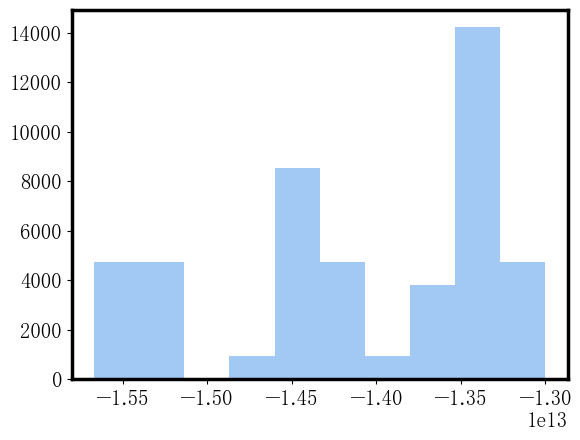

In [48]:
(co2flux_change['co2flux']/alk_mask['alk_flux']).plot()